# 08 - Homogeneous Dimension Scaling

This notebook isolates the effect of basket dimension `N` by making the assets homogeneous.

Relative to notebook 07, this removes the main confound: basket composition. For each `N`, the basket now has:

- identical spot levels,
- identical volatilities,
- zero dividends,
- equal weights.

The only thing that changes across scenarios is the basket dimension itself.

The true world still uses the same harsh regime-switching dependence structure:

- constant hedge model uses `rho = 0.35`,
- calm regime uses `rho = 0.20`,
- stress regime uses `rho = 0.98`,
- long-run stress share is `40%`,
- monthly delta hedging only.

In [1]:
from pathlib import Path
import time

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display

plt.style.use("seaborn-v0_8-whitegrid")
np.set_printoptions(precision=4, suppress=True)

In [2]:
base_dir = Path.cwd()
repo_root = base_dir.parent if base_dir.name == "notebooks" else base_dir
data_dir = repo_root / "data" / "synthetic"

spot_level = 100.0
vol_level = 0.22
rate = 0.03
maturity = 1.0
start_regime = 0

rho_constant_level = 0.35
rho_calm_level = 0.20
rho_stress_level = 0.98
stress_share_target = 0.40
lambda_daily = 0.08

n_assets_grid = [2, 3, 4, 5, 6, 8, 10]
hedge_steps = 12

n_true_world_paths = 100
delta_mc_paths = 1000
initial_price_mc_paths = 10000
repeat_count = 5
bump_fraction = 0.01

config = pd.Series(
    {
        "spot_level": spot_level,
        "vol_level": vol_level,
        "rho_constant": rho_constant_level,
        "rho_calm": rho_calm_level,
        "rho_stress": rho_stress_level,
        "stress_share_target": stress_share_target,
        "lambda_daily": lambda_daily,
        "hedge_steps": hedge_steps,
        "true_world_paths": n_true_world_paths,
        "delta_mc_paths": delta_mc_paths,
        "initial_price_mc_paths": initial_price_mc_paths,
        "repeat_count": repeat_count,
        "bump_fraction": bump_fraction,
    },
    name="value",
)

display(config.to_frame())

,value
spot_level,100.00
vol_level,0.22
rho_constant,0.35
rho_calm,0.20
rho_stress,0.98
stress_share_target,0.40
lambda_daily,0.08
hedge_steps,12.00
true_world_paths,100.00
delta_mc_paths,1000.00


## Shared Helpers

The pricing and hedging engine is unchanged. Only the asset inputs are now homogeneous, so the dimension sweep is much easier to interpret.

In [3]:
def basket_values(prices, weights):
    return prices @ weights


def basket_call_payoff(prices, weights, strike):
    return np.maximum(basket_values(prices, weights) - strike, 0.0)


def maturity_delta(spot, weights, strike):
    basket_level = float(weights @ spot)
    if basket_level > strike:
        return weights.copy()
    if np.isclose(basket_level, strike):
        return 0.5 * weights
    return np.zeros_like(weights)


def equicorrelation_matrix(n_assets, rho):
    corr = np.full((n_assets, n_assets), rho)
    np.fill_diagonal(corr, 1.0)
    return corr


def build_transition_matrix(p01_daily, p10_daily):
    return np.array(
        [
            [1.0 - p01_daily, p01_daily],
            [p10_daily, 1.0 - p10_daily],
        ]
    )


def correlate_draws(base_draws, regime_states, chol_by_regime):
    correlated = np.empty_like(base_draws)
    for regime_value, chol in chol_by_regime.items():
        mask = regime_states == regime_value
        if np.any(mask):
            correlated[mask] = base_draws[mask] @ chol.T
    return correlated


def advance_regimes(current_regimes, transition_matrix, rng):
    prob_to_stress = transition_matrix[current_regimes, 1]
    draws = rng.random(current_regimes.size)
    return (draws < prob_to_stress).astype(np.int8)


def simulate_regime_true_world_paths(
    spot,
    rate,
    div_yield,
    vol,
    chol_calm,
    chol_stress,
    maturity,
    hedge_steps,
    n_paths,
    transition_hedge,
    start_regime,
    rng,
):
    dt = maturity / hedge_steps
    drift = (rate - div_yield - 0.5 * vol ** 2) * dt
    diffusion = vol * np.sqrt(dt)
    chol_by_regime = {0: chol_calm, 1: chol_stress}

    paths = np.empty((n_paths, hedge_steps + 1, spot.size))
    regimes = np.empty((n_paths, hedge_steps), dtype=np.int8)
    paths[:, 0, :] = spot
    current_regimes = np.full(n_paths, start_regime, dtype=np.int8)

    for step in range(hedge_steps):
        regimes[:, step] = current_regimes
        base_draws = rng.standard_normal((n_paths, spot.size))
        correlated_draws = correlate_draws(base_draws, current_regimes, chol_by_regime)
        log_increment = drift + diffusion * correlated_draws
        paths[:, step + 1, :] = paths[:, step, :] * np.exp(log_increment)

        if step < hedge_steps - 1:
            current_regimes = advance_regimes(current_regimes, transition_hedge, rng)

    return paths, regimes


def constant_model_terminal_factors(spot, rate, div_yield, vol, tau, chol_constant, n_samples, rng):
    if tau <= 0.0:
        return np.ones((n_samples, spot.size))
    drift = (rate - div_yield - 0.5 * vol ** 2) * tau
    diffusion = vol * np.sqrt(tau)
    shocks = rng.standard_normal((n_samples, spot.size)) @ chol_constant.T
    return np.exp(drift + diffusion * shocks)


def regime_model_terminal_factors(
    spot,
    rate,
    div_yield,
    vol,
    hedge_dt,
    steps_remaining,
    chol_calm,
    chol_stress,
    transition_hedge,
    start_regime,
    n_samples,
    rng,
):
    if steps_remaining <= 0:
        return np.ones((n_samples, spot.size))

    drift = (rate - div_yield - 0.5 * vol ** 2) * hedge_dt
    diffusion = vol * np.sqrt(hedge_dt)
    chol_by_regime = {0: chol_calm, 1: chol_stress}
    current_regimes = np.full(n_samples, start_regime, dtype=np.int8)
    log_factors = np.zeros((n_samples, spot.size))

    for step in range(steps_remaining):
        base_draws = rng.standard_normal((n_samples, spot.size))
        correlated_draws = correlate_draws(base_draws, current_regimes, chol_by_regime)
        log_factors += drift + diffusion * correlated_draws
        if step < steps_remaining - 1:
            current_regimes = advance_regimes(current_regimes, transition_hedge, rng)

    return np.exp(log_factors)

In [4]:
def price_and_delta_from_terminal_factors(spot, terminal_factors, weights, strike, rate, tau, bump_fraction):
    terminal_prices = terminal_factors * spot
    discount = np.exp(-rate * tau)
    price = discount * basket_call_payoff(terminal_prices, weights, strike).mean()

    bump_sizes = bump_fraction * np.maximum(spot, 1.0)
    deltas = np.empty_like(spot)
    for asset_idx in range(spot.size):
        up_spot = spot[asset_idx] + bump_sizes[asset_idx]
        down_spot = max(spot[asset_idx] - bump_sizes[asset_idx], 1e-8)
        denominator = up_spot - down_spot

        up_terminal = terminal_prices.copy()
        down_terminal = terminal_prices.copy()
        up_terminal[:, asset_idx] = terminal_factors[:, asset_idx] * up_spot
        down_terminal[:, asset_idx] = terminal_factors[:, asset_idx] * down_spot

        up_payoff = basket_call_payoff(up_terminal, weights, strike)
        down_payoff = basket_call_payoff(down_terminal, weights, strike)
        deltas[asset_idx] = discount * (up_payoff.mean() - down_payoff.mean()) / denominator

    return price, deltas


def constant_model_price_and_delta(spot, tau, weights, strike, rate, div_yield, vol, chol_constant, n_samples, bump_fraction, rng):
    if tau <= 0.0:
        payoff = float(basket_call_payoff(spot[None, :], weights, strike)[0])
        return payoff, maturity_delta(spot, weights, strike)
    terminal_factors = constant_model_terminal_factors(spot, rate, div_yield, vol, tau, chol_constant, n_samples, rng)
    return price_and_delta_from_terminal_factors(spot, terminal_factors, weights, strike, rate, tau, bump_fraction)


def regime_model_price_and_delta(
    spot,
    steps_remaining,
    current_regime,
    weights,
    strike,
    rate,
    div_yield,
    vol,
    hedge_dt,
    chol_calm,
    chol_stress,
    transition_hedge,
    n_samples,
    bump_fraction,
    rng,
):
    tau = steps_remaining * hedge_dt
    if steps_remaining <= 0:
        payoff = float(basket_call_payoff(spot[None, :], weights, strike)[0])
        return payoff, maturity_delta(spot, weights, strike)
    terminal_factors = regime_model_terminal_factors(
        spot,
        rate,
        div_yield,
        vol,
        hedge_dt,
        steps_remaining,
        chol_calm,
        chol_stress,
        transition_hedge,
        current_regime,
        n_samples,
        rng,
    )
    return price_and_delta_from_terminal_factors(spot, terminal_factors, weights, strike, rate, tau, bump_fraction)


def pnl_summary(pnl):
    return {
        "mean_pnl": float(np.mean(pnl)),
        "std_pnl": float(np.std(pnl, ddof=1)),
        "q05_pnl": float(np.quantile(pnl, 0.05)),
        "q01_pnl": float(np.quantile(pnl, 0.01)),
    }


def evaluate_hedger(true_paths, true_regimes, hedge_model, pricing_inputs, base_seed):
    time_start = time.perf_counter()

    if hedge_model == "constant":
        initial_price, initial_delta = constant_model_price_and_delta(
            spot=pricing_inputs["spot"],
            tau=pricing_inputs["maturity"],
            weights=pricing_inputs["weights"],
            strike=pricing_inputs["strike"],
            rate=pricing_inputs["rate"],
            div_yield=pricing_inputs["div_yield"],
            vol=pricing_inputs["vol"],
            chol_constant=pricing_inputs["chol_constant"],
            n_samples=pricing_inputs["initial_price_mc_paths"],
            bump_fraction=pricing_inputs["bump_fraction"],
            rng=np.random.default_rng(base_seed + 1),
        )
    else:
        initial_price, initial_delta = regime_model_price_and_delta(
            spot=pricing_inputs["spot"],
            steps_remaining=pricing_inputs["hedge_steps"],
            current_regime=pricing_inputs["start_regime"],
            weights=pricing_inputs["weights"],
            strike=pricing_inputs["strike"],
            rate=pricing_inputs["rate"],
            div_yield=pricing_inputs["div_yield"],
            vol=pricing_inputs["vol"],
            hedge_dt=pricing_inputs["hedge_dt"],
            chol_calm=pricing_inputs["chol_calm"],
            chol_stress=pricing_inputs["chol_stress"],
            transition_hedge=pricing_inputs["transition_hedge"],
            n_samples=pricing_inputs["initial_price_mc_paths"],
            bump_fraction=pricing_inputs["bump_fraction"],
            rng=np.random.default_rng(base_seed + 2),
        )

    terminal_payoff = basket_call_payoff(true_paths[:, -1, :], pricing_inputs["weights"], pricing_inputs["strike"])
    n_paths = true_paths.shape[0]
    cash_account = np.full(n_paths, initial_price) - true_paths[:, 0, :] @ initial_delta
    delta_holdings = np.tile(initial_delta, (n_paths, 1))

    for step in range(pricing_inputs["hedge_steps"] - 1):
        next_spots = true_paths[:, step + 1, :]
        cash_account *= np.exp(pricing_inputs["rate"] * pricing_inputs["hedge_dt"])
        portfolio_before = cash_account + np.sum(delta_holdings * next_spots, axis=1)
        remaining_steps = pricing_inputs["hedge_steps"] - (step + 1)
        new_deltas = np.empty_like(delta_holdings)

        for path_idx in range(n_paths):
            state_rng = np.random.default_rng(base_seed + 10000 * (step + 1) + path_idx)
            if hedge_model == "constant":
                _, state_delta = constant_model_price_and_delta(
                    spot=next_spots[path_idx],
                    tau=remaining_steps * pricing_inputs["hedge_dt"],
                    weights=pricing_inputs["weights"],
                    strike=pricing_inputs["strike"],
                    rate=pricing_inputs["rate"],
                    div_yield=pricing_inputs["div_yield"],
                    vol=pricing_inputs["vol"],
                    chol_constant=pricing_inputs["chol_constant"],
                    n_samples=pricing_inputs["delta_mc_paths"],
                    bump_fraction=pricing_inputs["bump_fraction"],
                    rng=state_rng,
                )
            else:
                _, state_delta = regime_model_price_and_delta(
                    spot=next_spots[path_idx],
                    steps_remaining=remaining_steps,
                    current_regime=int(true_regimes[path_idx, step + 1]),
                    weights=pricing_inputs["weights"],
                    strike=pricing_inputs["strike"],
                    rate=pricing_inputs["rate"],
                    div_yield=pricing_inputs["div_yield"],
                    vol=pricing_inputs["vol"],
                    hedge_dt=pricing_inputs["hedge_dt"],
                    chol_calm=pricing_inputs["chol_calm"],
                    chol_stress=pricing_inputs["chol_stress"],
                    transition_hedge=pricing_inputs["transition_hedge"],
                    n_samples=pricing_inputs["delta_mc_paths"],
                    bump_fraction=pricing_inputs["bump_fraction"],
                    rng=state_rng,
                )
            new_deltas[path_idx] = state_delta

        cash_account = portfolio_before - np.sum(new_deltas * next_spots, axis=1)
        delta_holdings = new_deltas

    cash_account *= np.exp(pricing_inputs["rate"] * pricing_inputs["hedge_dt"])
    pnl = cash_account + np.sum(delta_holdings * true_paths[:, -1, :], axis=1) - terminal_payoff

    return {
        "runtime_seconds": float(time.perf_counter() - time_start),
        "initial_price": initial_price,
        **pnl_summary(pnl),
    }

In [5]:
def run_homogeneous_dimension_scenario(n_assets, repeat_id, scenario_seed):
    spot = np.full(n_assets, spot_level)
    vol = np.full(n_assets, vol_level)
    div_yield = np.zeros(n_assets)
    weights = np.full(n_assets, 1.0 / n_assets)
    strike = float(weights @ spot)

    p01_daily = stress_share_target * lambda_daily
    p10_daily = (1.0 - stress_share_target) * lambda_daily
    transition_daily = build_transition_matrix(p01_daily, p10_daily)
    transition_hedge = np.linalg.matrix_power(transition_daily, 252 // hedge_steps)

    chol_constant = np.linalg.cholesky(equicorrelation_matrix(n_assets, rho_constant_level))
    chol_calm = np.linalg.cholesky(equicorrelation_matrix(n_assets, rho_calm_level))
    chol_stress = np.linalg.cholesky(equicorrelation_matrix(n_assets, rho_stress_level))

    pricing_inputs = {
        "spot": spot,
        "weights": weights,
        "strike": strike,
        "rate": rate,
        "div_yield": div_yield,
        "vol": vol,
        "maturity": maturity,
        "hedge_steps": hedge_steps,
        "hedge_dt": maturity / hedge_steps,
        "delta_mc_paths": delta_mc_paths,
        "initial_price_mc_paths": initial_price_mc_paths,
        "bump_fraction": bump_fraction,
        "chol_constant": chol_constant,
        "chol_calm": chol_calm,
        "chol_stress": chol_stress,
        "transition_hedge": transition_hedge,
        "start_regime": start_regime,
    }

    true_paths, true_regimes = simulate_regime_true_world_paths(
        spot=spot,
        rate=rate,
        div_yield=div_yield,
        vol=vol,
        chol_calm=chol_calm,
        chol_stress=chol_stress,
        maturity=maturity,
        hedge_steps=hedge_steps,
        n_paths=n_true_world_paths,
        transition_hedge=transition_hedge,
        start_regime=start_regime,
        rng=np.random.default_rng(scenario_seed),
    )

    rows = []
    for hedger_idx, hedger in enumerate(["constant", "regime"]):
        summary = evaluate_hedger(
            true_paths=true_paths,
            true_regimes=true_regimes,
            hedge_model=hedger,
            pricing_inputs=pricing_inputs,
            base_seed=scenario_seed + 1000 * (hedger_idx + 1),
        )
        rows.append(
            {
                "n_assets": n_assets,
                "repeat_id": repeat_id,
                "strike": strike,
                "avg_stress_fraction": float(true_regimes.mean()),
                "hedger": hedger,
                **summary,
            }
        )

    return pd.DataFrame(rows)


raw_rows = []
for n_idx, n_assets in enumerate(n_assets_grid, start=1):
    for repeat_id in range(repeat_count):
        scenario_seed = 150000 + 11000 * n_idx + 300 * repeat_id
        raw_rows.append(run_homogeneous_dimension_scenario(n_assets, repeat_id, scenario_seed))

homogeneous_raw = pd.concat(raw_rows, ignore_index=True)

homogeneous_summary = (
    homogeneous_raw.groupby(["n_assets", "hedger"], as_index=False)
    .agg(
        avg_initial_price=("initial_price", "mean"),
        avg_mean_pnl=("mean_pnl", "mean"),
        avg_std_pnl=("std_pnl", "mean"),
        std_of_std_pnl=("std_pnl", "std"),
        avg_q05_pnl=("q05_pnl", "mean"),
        avg_q01_pnl=("q01_pnl", "mean"),
        std_of_q01_pnl=("q01_pnl", "std"),
        avg_runtime_seconds=("runtime_seconds", "mean"),
        avg_stress_fraction=("avg_stress_fraction", "mean"),
    )
)

homogeneous_gap = homogeneous_summary.pivot(
    index="n_assets",
    columns="hedger",
    values=["avg_initial_price", "avg_std_pnl", "avg_q05_pnl", "avg_q01_pnl", "avg_mean_pnl", "avg_runtime_seconds"],
)
homogeneous_gap.columns = ["_".join(col).strip() for col in homogeneous_gap.columns.to_flat_index()]
homogeneous_gap = homogeneous_gap.reset_index()
homogeneous_gap["regime_price_minus_constant"] = homogeneous_gap["avg_initial_price_regime"] - homogeneous_gap["avg_initial_price_constant"]
homogeneous_gap["std_gap_constant_minus_regime"] = homogeneous_gap["avg_std_pnl_constant"] - homogeneous_gap["avg_std_pnl_regime"]
homogeneous_gap["q05_gap_regime_minus_constant"] = homogeneous_gap["avg_q05_pnl_regime"] - homogeneous_gap["avg_q05_pnl_constant"]
homogeneous_gap["q01_gap_regime_minus_constant"] = homogeneous_gap["avg_q01_pnl_regime"] - homogeneous_gap["avg_q01_pnl_constant"]
homogeneous_gap["mean_gap_regime_minus_constant"] = homogeneous_gap["avg_mean_pnl_regime"] - homogeneous_gap["avg_mean_pnl_constant"]

display(homogeneous_summary.round(4))
display(homogeneous_gap.round(4))

,n_assets,hedger,avg_initial_price,avg_mean_pnl,avg_std_pnl,std_of_std_pnl,avg_q05_pnl,avg_q01_pnl,std_of_q01_pnl,avg_runtime_seconds,avg_stress_fraction
0,2,constant,8.8082,-0.1798,2.0016,0.1160,-3.5322,-5.6101,1.1495,0.2088,0.3738
1,2,regime,9.0345,0.0602,1.9563,0.1358,-3.3647,-4.9075,0.8641,0.6358,0.3738
2,3,constant,8.0792,-0.4803,1.8644,0.1627,-3.5354,-4.7027,0.4886,0.2348,0.3685
3,3,regime,8.4950,-0.0373,1.8877,0.1489,-2.9289,-4.3025,0.6613,0.7122,0.3685
4,4,constant,7.8349,-0.6581,2.0822,0.2550,-4.3272,-6.4458,1.2494,0.2794,0.3567
5,4,regime,8.2684,-0.2130,1.9964,0.1961,-3.7873,-5.1777,1.2977,0.8157,0.3567
6,5,constant,7.5988,-0.7811,1.9442,0.1769,-4.3026,-6.3710,1.2560,0.3309,0.3563
7,5,regime,8.1646,-0.2354,1.9259,0.1642,-3.5266,-5.5065,1.0391,0.9033,0.3563
8,6,constant,7.4823,-0.6454,1.9776,0.1641,-3.5910,-6.9801,1.7949,0.3707,0.3568
9,6,regime,8.0583,-0.0456,1.9475,0.1219,-3.0798,-5.7565,1.6905,0.9900,0.3568


,n_assets,avg_initial_price_constant,avg_initial_price_regime,avg_std_pnl_constant,avg_std_pnl_regime,avg_q05_pnl_constant,avg_q05_pnl_regime,avg_q01_pnl_constant,avg_q01_pnl_regime,avg_mean_pnl_constant,avg_mean_pnl_regime,avg_runtime_seconds_constant,avg_runtime_seconds_regime,regime_price_minus_constant,std_gap_constant_minus_regime,q05_gap_regime_minus_constant,q01_gap_regime_minus_constant,mean_gap_regime_minus_constant
0,2,8.8082,9.0345,2.0016,1.9563,-3.5322,-3.3647,-5.6101,-4.9075,-0.1798,0.0602,0.2088,0.6358,0.2263,0.0453,0.1675,0.7026,0.2400
1,3,8.0792,8.4950,1.8644,1.8877,-3.5354,-2.9289,-4.7027,-4.3025,-0.4803,-0.0373,0.2348,0.7122,0.4158,-0.0233,0.6065,0.4002,0.4431
2,4,7.8349,8.2684,2.0822,1.9964,-4.3272,-3.7873,-6.4458,-5.1777,-0.6581,-0.2130,0.2794,0.8157,0.4334,0.0858,0.5400,1.2681,0.4451
3,5,7.5988,8.1646,1.9442,1.9259,-4.3026,-3.5266,-6.3710,-5.5065,-0.7811,-0.2354,0.3309,0.9033,0.5658,0.0183,0.7760,0.8644,0.5457
4,6,7.4823,8.0583,1.9776,1.9475,-3.5910,-3.0798,-6.9801,-5.7565,-0.6454,-0.0456,0.3707,0.9900,0.5760,0.0301,0.5112,1.2236,0.5998
5,8,7.2956,7.9377,2.0415,2.0203,-4.1764,-3.2807,-7.1463,-5.2676,-0.6439,0.0092,0.4605,1.1548,0.6421,0.0212,0.8957,1.8787,0.6532
6,10,7.2372,7.9072,2.1841,2.1227,-4.7438,-3.4441,-7.4633,-5.5850,-0.6735,0.0002,1.2373,4.1668,0.6700,0.0614,1.2997,1.8783,0.6737


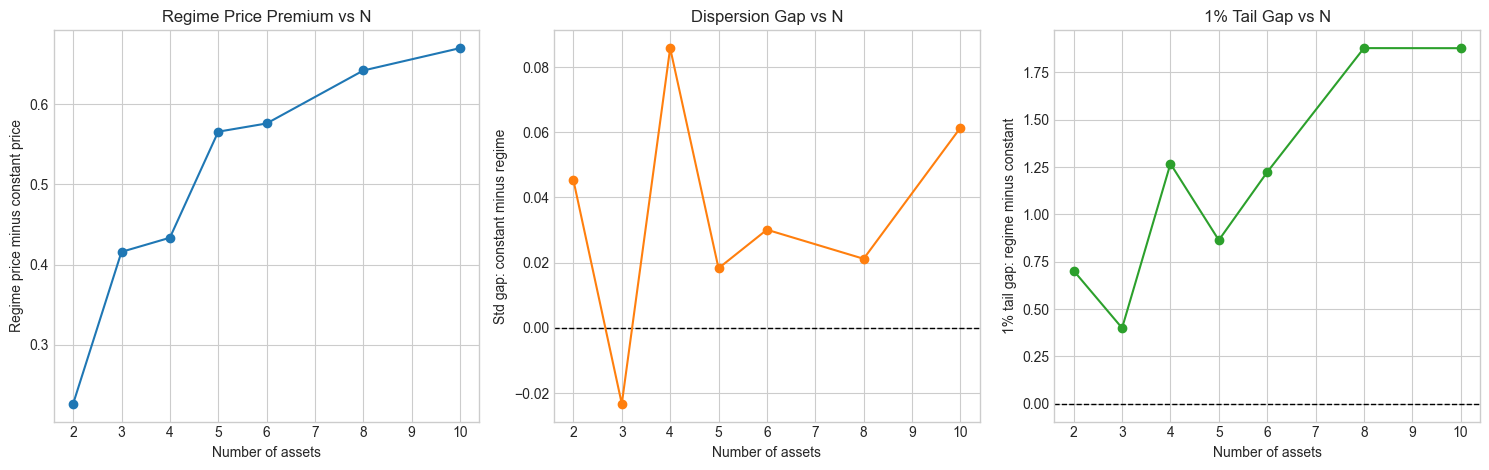

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.8))

axes[0].plot(homogeneous_gap["n_assets"], homogeneous_gap["regime_price_minus_constant"], marker="o", color="tab:blue")
axes[0].set_title("Regime Price Premium vs N")
axes[0].set_xlabel("Number of assets")
axes[0].set_ylabel("Regime price minus constant price")

axes[1].axhline(0.0, color="black", linestyle="--", linewidth=1.0)
axes[1].plot(homogeneous_gap["n_assets"], homogeneous_gap["std_gap_constant_minus_regime"], marker="o", color="tab:orange")
axes[1].set_title("Dispersion Gap vs N")
axes[1].set_xlabel("Number of assets")
axes[1].set_ylabel("Std gap: constant minus regime")

axes[2].axhline(0.0, color="black", linestyle="--", linewidth=1.0)
axes[2].plot(homogeneous_gap["n_assets"], homogeneous_gap["q01_gap_regime_minus_constant"], marker="o", color="tab:green")
axes[2].set_title("1% Tail Gap vs N")
axes[2].set_xlabel("Number of assets")
axes[2].set_ylabel("1% tail gap: regime minus constant")

plt.tight_layout()
plt.show()

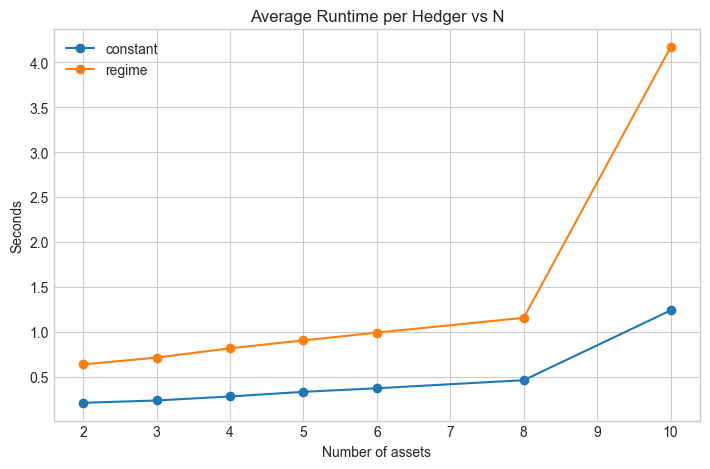

In [7]:
fig, ax = plt.subplots(figsize=(7.2, 4.8))

for hedger, frame in homogeneous_summary.groupby("hedger"):
    frame = frame.sort_values("n_assets")
    ax.plot(frame["n_assets"], frame["avg_runtime_seconds"], marker="o", label=hedger)

ax.set_title("Average Runtime per Hedger vs N")
ax.set_xlabel("Number of assets")
ax.set_ylabel("Seconds")
ax.legend()

plt.tight_layout()
plt.show()

## Interpretation

In this homogeneous setup, the dimension question is much cleaner. Focus on:

- `regime_price_minus_constant`: how much the harsher dependence structure raises the option value,
- `q01_gap_regime_minus_constant`: how much the regime hedge improves the left tail,
- `std_gap_constant_minus_regime`: the overall dispersion gap, which is usually smaller and noisier.

If the first and third notebook lines were confusing because composition changed with `N`, this notebook is the correct comparison to trust when talking about pure dimension dependence.

In [8]:
homogeneous_raw.to_csv(data_dir / "basket_option_homogeneous_dimension_raw.csv", index=False)
homogeneous_summary.to_csv(data_dir / "basket_option_homogeneous_dimension_summary.csv", index=False)
homogeneous_gap.to_csv(data_dir / "basket_option_homogeneous_dimension_gap.csv", index=False)
config.to_csv(data_dir / "basket_option_homogeneous_dimension_config.csv")

print(f"Saved raw homogeneous dimension runs to {data_dir / 'basket_option_homogeneous_dimension_raw.csv'}")
print(f"Saved homogeneous dimension summary to {data_dir / 'basket_option_homogeneous_dimension_summary.csv'}")
print(f"Saved homogeneous dimension gap table to {data_dir / 'basket_option_homogeneous_dimension_gap.csv'}")
print(f"Saved homogeneous dimension config to {data_dir / 'basket_option_homogeneous_dimension_config.csv'}")

Saved raw homogeneous dimension runs to /Users/hamzaahmed/Multi-Asset Option Pricing/data/synthetic/basket_option_homogeneous_dimension_raw.csv
Saved homogeneous dimension summary to /Users/hamzaahmed/Multi-Asset Option Pricing/data/synthetic/basket_option_homogeneous_dimension_summary.csv
Saved homogeneous dimension gap table to /Users/hamzaahmed/Multi-Asset Option Pricing/data/synthetic/basket_option_homogeneous_dimension_gap.csv
Saved homogeneous dimension config to /Users/hamzaahmed/Multi-Asset Option Pricing/data/synthetic/basket_option_homogeneous_dimension_config.csv
